# 🤝 Gemastik 2026: Multimodal Video + Audio AI Detection & Ensemble Evaluation
This notebook evaluates your fine-tuned **Video ViT Model (`dima806`)** and **Audio Wav2Vec2 Model (`MelodyMachine`)** saved in Google Drive.

It evaluates performance on two separate sets of data:
1. 🧪 **Validation Split:** The 20% holdout split (deterministic from `val_split.json`) used during training.
2. 🏁 **Unseen Test Dataset:** Extracted from `testReal.zip` and `testAI.zip` to verify final generalization.

---

### 📊 Late Fusion Ensemble formula:
$$P_{\text{multimodal}} = w_{\text{video}} \cdot P_{\text{video}} + w_{\text{audio}} \cdot P_{\text{audio}}$$


## 1. Setup Environment & Mount Google Drive

In [44]:
# Install required libraries
!pip install -q transformers timm albumentations opencv-python-headless soundfile librosa scikit-learn matplotlib seaborn tqdm pandas

import os
import glob
import shutil
import random
import zipfile
import subprocess
import json
import pandas as pd
import numpy as np
import cv2
import librosa
import soundfile as sf
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification, AutoFeatureExtractor, AutoModelForAudioClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path

# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set seed for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA Available:", torch.cuda.is_available())
print("Device:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA Available: True
Device: cuda


## 2. Model & Dataset Paths Setup

In [45]:
# Drive Paths
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models"
VAL_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/val_split.json"

# Validation zip paths (used during training)
ZIP_VAL_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip")
}

# Unseen final test zip paths (directly under Dataset Indonesia/)
ZIP_TEST_PATHS = {
    "Real": os.path.join(DRIVE_DATASET_DIR, "testReal.zip"),
    "AI": os.path.join(DRIVE_DATASET_DIR, "testAI.zip")
}

# Local Colab SSD paths
LOCAL_RAW_VAL_DIR = "/content/dataset_raw"
LOCAL_RAW_TEST_DIR = "/content/dataset_test"

# Fine-Tuned Saved Model Paths in Google Drive (searches both models/ subfolder and Gemastik26/ root)
def get_latest_model_path(base_name):
    search_dirs = [
        MODEL_SAVE_DIR,
        "/content/drive/MyDrive/Gemastik26"
    ]
    matching = []
    for s_dir in search_dirs:
        if os.path.exists(s_dir):
            matching.extend([d for d in glob.glob(os.path.join(s_dir, f"{base_name}*")) if os.path.isdir(d)])
            
    if not matching:
        raise FileNotFoundError(f"No model folder found matching '{base_name}' in models/ or Gemastik26/ folders.")
    matching.sort()
    return matching[-1]

# Default to loading the Augmented Models (best general performance)
VIDEO_MODEL_PATH = get_latest_model_path("dima806_deepfake_aug")
AUDIO_MODEL_PATH = get_latest_model_path("melody_audio_deepfake_aug")

# To evaluate raw baseline models instead, uncomment the lines below:
# VIDEO_MODEL_PATH = get_latest_model_path("dima806_deepfake_raw")
# AUDIO_MODEL_PATH = get_latest_model_path("melody_audio_deepfake_raw")

CLASSES = ["Real", "AI"]
VAL_SPLIT = 0.2
IMAGE_SIZE = (224, 224)
SAMPLE_RATE = 16000
CHUNK_SEC = 5.0
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * CHUNK_SEC)

print(f"📹 Selected Video Model: {VIDEO_MODEL_PATH}")
print(f"🎙️ Selected Audio Model: {AUDIO_MODEL_PATH}")
print(f"📂 Validation Split File: {VAL_SPLIT_FILE}")


📹 Selected Video Model: /content/drive/MyDrive/Gemastik26/models/dima806_deepfake_aug_20260802_1452
🎙️ Selected Audio Model: /content/drive/MyDrive/Gemastik26/models/melody_audio_deepfake_aug
📂 Validation Split File: /content/drive/MyDrive/Gemastik26/val_split.json


## 3. Unzip Video Archives to Colab SSD (Smart Skip)

In [47]:
def unzip_file(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"⚠️ Warning: Zip file not found at {zip_path}")
        return False
    print(f"📦 Unzipping {zip_path} -> {extract_to} ...")
    os.makedirs(extract_to, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")
    return True

# Unzip validation sets (if needed)
for cls in CLASSES:
    target_dir = os.path.join(LOCAL_RAW_VAL_DIR, cls)
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"📂 Validation videos for '{cls}' already unzipped. Skipping!")
    else:
        unzip_file(ZIP_VAL_PATHS[cls], target_dir)

# Unzip test sets
for cls in CLASSES:
    target_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"📂 Test videos for '{cls}' already unzipped. Skipping!")
    else:
        unzip_file(ZIP_TEST_PATHS[cls], target_dir)

print("All datasets extracted successfully!")


📂 Validation videos for 'Real' already unzipped. Skipping!
📂 Validation videos for 'AI' already unzipped. Skipping!
📂 Test videos for 'Real' already unzipped. Skipping!
📂 Test videos for 'AI' already unzipped. Skipping!
All datasets extracted successfully!


## 4. Load Saved Video & Audio Models

In [48]:
print("⏳ Loading Video ViT Model & Processor ...")
video_processor = AutoImageProcessor.from_pretrained(VIDEO_MODEL_PATH)
video_model = AutoModelForImageClassification.from_pretrained(VIDEO_MODEL_PATH).to(device)
video_model.eval()

print("⏳ Loading Audio Wav2Vec2 Model & Feature Extractor ...")
audio_feature_extractor = AutoFeatureExtractor.from_pretrained(AUDIO_MODEL_PATH)
audio_model = AutoModelForAudioClassification.from_pretrained(AUDIO_MODEL_PATH).to(device)
audio_model.eval()

print("✅ Both Video and Audio Models Loaded Successfully!")

# Transforms
video_val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=video_processor.image_mean, std=video_processor.image_std)
])


⏳ Loading Video ViT Model & Processor ...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

⏳ Loading Audio Wav2Vec2 Model & Feature Extractor ...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

✅ Both Video and Audio Models Loaded Successfully!


## 5. Load Validation Set from Drive Split File

In [49]:
import json

# Force Drive FUSE cache sync
drive_parent = os.path.dirname(VAL_SPLIT_FILE)
if os.path.exists(drive_parent):
    try:
        _ = os.listdir(drive_parent)
    except Exception:
        pass

all_val_videos = []

for label_idx, cls in enumerate(CLASSES):
    cls_raw_dir = os.path.join(LOCAL_RAW_VAL_DIR, cls)
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))

    for vfile in video_files:
        all_val_videos.append((vfile, label_idx, cls, Path(vfile).stem))

# Load split
if os.path.exists(VAL_SPLIT_FILE):
    with open(VAL_SPLIT_FILE, "r") as f:
        split_data = json.load(f)
    val_stems = set(split_data["val_stems"])
    print(f"📂 Validation Split loaded from Drive: {VAL_SPLIT_FILE}")
else:
    print(f"💾 Generating fallback split (no existing file found)...")
    all_val_videos.sort(key=lambda x: x[3])
    random.seed(42)
    random.shuffle(all_val_videos)
    num_val = int(len(all_val_videos) * VAL_SPLIT)
    val_stems = set([x[3] for x in all_val_videos[:num_val]])

val_videos = [x for x in all_val_videos if x[3] in val_stems]

print(f"Validation videos: {len(val_videos)} (filtered using val_split.json)")


📂 Validation Split loaded from Drive: /content/drive/MyDrive/Gemastik26/val_split.json
Validation videos: 212 (filtered using val_split.json)


## 6. Inference Helper Functions

In [50]:
def extract_frames_from_video(video_path, target_fps=1.0, max_frames=30):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    if video_fps <= 0 or np.isnan(video_fps):
        video_fps = 30.0

    frame_interval = max(1, int(round(video_fps / target_fps)))
    frames = []
    count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(frame_rgb)
            frames.append(img)
            if len(frames) >= max_frames:
                break
        count += 1

    cap.release()
    return frames

def extract_audio_chunks(video_path, temp_dir="/content/temp_eval_audio", chunk_sec=5.0):
    os.makedirs(temp_dir, exist_ok=True)
    temp_wav = os.path.join(temp_dir, "_temp.wav")
    
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vn", "-acodec", "pcm_s16le", "-ar", str(SAMPLE_RATE), "-ac", "1",
        temp_wav
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    if not os.path.exists(temp_wav) or os.path.getsize(temp_wav) < 1000:
        return []

    y, sr = sf.read(temp_wav)
    os.remove(temp_wav)
    
    chunk_samples = int(chunk_sec * sr)
    total_samples = len(y)
    if total_samples == 0:
        return []

    num_chunks = max(1, int(np.ceil(total_samples / chunk_samples)))
    chunks = []
    for i in range(num_chunks):
        start = i * chunk_samples
        end = min(total_samples, (i + 1) * chunk_samples)
        cdata = y[start:end]
        if len(cdata) < int(1.0 * sr):
            continue
        if len(cdata) < chunk_samples:
            cdata = np.pad(cdata, (0, chunk_samples - len(cdata)), mode='constant')
        chunks.append(cdata)

    return chunks

def predict_video_probs(video_path):
    frames = extract_frames_from_video(video_path, target_fps=1.0, max_frames=30)
    if not frames:
        return np.array([0.5, 0.5])

    probs_list = []
    with torch.no_grad():
        for img in frames:
            tensor_img = video_val_transform(img).unsqueeze(0).to(device)
            outputs = video_model(tensor_img)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            probs_list.append(probs)

    return np.mean(probs_list, axis=0)

def predict_audio_probs(video_path):
    chunks = extract_audio_chunks(video_path)
    if not chunks:
        return np.array([0.5, 0.5])

    probs_list = []
    with torch.no_grad():
        for cdata in chunks:
            inputs = audio_feature_extractor(cdata, sampling_rate=SAMPLE_RATE, return_tensors="pt")
            input_values = inputs.input_values.to(device)
            outputs = audio_model(input_values)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            probs_list.append(probs)

    return np.mean(probs_list, axis=0)


## 7. Run Multimodal Ensemble on Validation Split
We evaluate validation split performance across:
1. **Video Model Alone**
2. **Audio Model Alone**
3. **Multimodal Late Fusion** ($0.5 \cdot P_{\text{video}} + 0.5 \cdot P_{\text{audio}}$)


In [51]:
val_targets = []
val_video_preds = []
val_audio_preds = []
val_fusion_preds = []

WEIGHT_VIDEO = 0.5
WEIGHT_AUDIO = 0.5

print(f"🚀 Evaluating {len(val_videos)} Validation Videos ...")

for vfile, label, cls_name, vid_stem in tqdm(val_videos, desc="Validation Evaluation"):
    val_targets.append(label)

    # Predictions
    p_vid = predict_video_probs(vfile)
    p_aud = predict_audio_probs(vfile)
    p_fusion = (WEIGHT_VIDEO * p_vid) + (WEIGHT_AUDIO * p_aud)

    val_video_preds.append(np.argmax(p_vid))
    val_audio_preds.append(np.argmax(p_aud))
    val_fusion_preds.append(np.argmax(p_fusion))

print("✅ Validation Evaluation Complete!")


🚀 Evaluating 212 Validation Videos ...


Validation Evaluation:   0%|          | 0/212 [00:00<?, ?it/s]

✅ Validation Evaluation Complete!


## 8. Validation Split Results & Confusion Matrices

📊 VALIDATION: VIDEO-ONLY MODEL PERFORMANCE
              precision    recall  f1-score   support

        Real       0.83      1.00      0.91       131
          AI       1.00      0.67      0.80        81

    accuracy                           0.87       212
   macro avg       0.91      0.83      0.85       212
weighted avg       0.89      0.87      0.87       212

📊 VALIDATION: AUDIO-ONLY MODEL PERFORMANCE
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99       131
          AI       1.00      0.98      0.99        81

    accuracy                           0.99       212
   macro avg       0.99      0.99      0.99       212
weighted avg       0.99      0.99      0.99       212

📊 VALIDATION: MULTIMODAL FUSION PERFORMANCE
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       131
          AI       1.00      1.00      1.00        81

    accuracy                           1.00       21

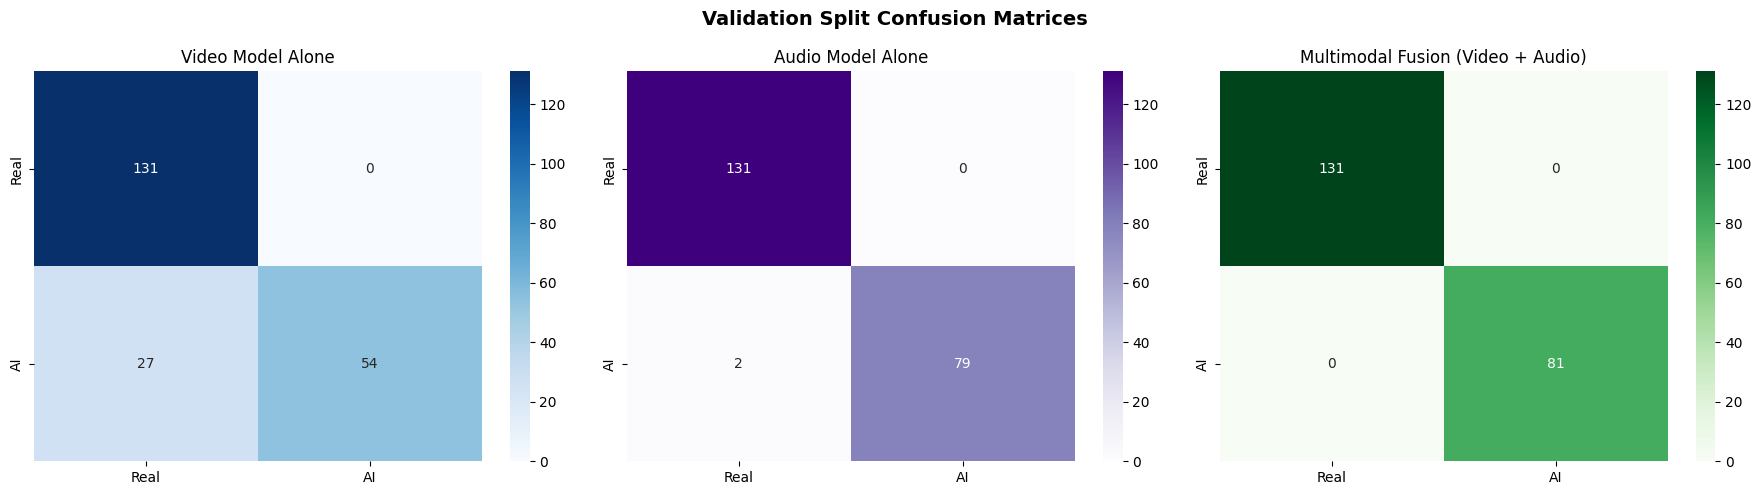

In [52]:
# Print Validation Reports
print("==================================================")
print("📊 VALIDATION: VIDEO-ONLY MODEL PERFORMANCE")
print("==================================================")
print(classification_report(val_targets, val_video_preds, target_names=CLASSES))

print("==================================================")
print("📊 VALIDATION: AUDIO-ONLY MODEL PERFORMANCE")
print("==================================================")
print(classification_report(val_targets, val_audio_preds, target_names=CLASSES))

print("==================================================")
print("📊 VALIDATION: MULTIMODAL FUSION PERFORMANCE")
print("==================================================")
print(classification_report(val_targets, val_fusion_preds, target_names=CLASSES))

# Plot Validation Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Validation Split Confusion Matrices", fontsize=14, fontweight='bold')

cm_vid = confusion_matrix(val_targets, val_video_preds)
sns.heatmap(cm_vid, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Video Model Alone")

cm_aud = confusion_matrix(val_targets, val_audio_preds)
sns.heatmap(cm_aud, annot=True, fmt="d", cmap="Purples", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title("Audio Model Alone")

cm_fusion = confusion_matrix(val_targets, val_fusion_preds)
sns.heatmap(cm_fusion, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title("Multimodal Fusion (Video + Audio)")

plt.tight_layout()
plt.show()


## 9. Run Multimodal Ensemble on Unseen Test Dataset
We evaluate generalization performance on the completely unseen test videos from `testReal.zip` and `testAI.zip`.


In [53]:
test_videos = []

for label_idx, cls in enumerate(CLASSES):
    cls_raw_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    video_extensions = ("*.mp4", "*.avi", "*.mov", "*.mkv", "*.MP4", "*.AVI", "*.MOV", "*.MKV")
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(cls_raw_dir, "**", ext), recursive=True))

    for vfile in video_files:
        test_videos.append((vfile, label_idx, cls, Path(vfile).stem))

test_targets = []
test_video_preds = []
test_audio_preds = []
test_fusion_preds = []

if not test_videos:
    print("❌ ERROR: No test videos found! Please check if your zip files exist at:")
    print(f"   - Real Test Zip: {ZIP_TEST_PATHS['Real']}")
    print(f"   - AI Test Zip:   {ZIP_TEST_PATHS['AI']}")
else:
    print(f"🚀 Evaluating {len(test_videos)} Unseen Test Videos ...")

    for vfile, label, cls_name, vid_stem in tqdm(test_videos, desc="Test Evaluation"):
        test_targets.append(label)

        # Predictions
        p_vid = predict_video_probs(vfile)
        p_aud = predict_audio_probs(vfile)
        p_fusion = (WEIGHT_VIDEO * p_vid) + (WEIGHT_AUDIO * p_aud)

        test_video_preds.append(np.argmax(p_vid))
        test_audio_preds.append(np.argmax(p_aud))
        test_fusion_preds.append(np.argmax(p_fusion))

    print("✅ Test Dataset Evaluation Complete!")


🚀 Evaluating 312 Unseen Test Videos ...


Test Evaluation:   0%|          | 0/312 [00:00<?, ?it/s]

✅ Test Dataset Evaluation Complete!


## 10. Unseen Test Dataset Results & Confusion Matrices

🏁 TEST DATASET: VIDEO-ONLY MODEL PERFORMANCE
              precision    recall  f1-score   support

        Real       0.77      0.99      0.86       190
          AI       0.98      0.52      0.68       122

    accuracy                           0.81       312
   macro avg       0.87      0.76      0.77       312
weighted avg       0.85      0.81      0.79       312

🏁 TEST DATASET: AUDIO-ONLY MODEL PERFORMANCE
              precision    recall  f1-score   support

        Real       0.96      0.99      0.98       190
          AI       0.99      0.94      0.97       122

    accuracy                           0.97       312
   macro avg       0.98      0.97      0.97       312
weighted avg       0.97      0.97      0.97       312

🏁 TEST DATASET: MULTIMODAL FUSION PERFORMANCE
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99       190
          AI       1.00      0.98      0.99       122

    accuracy                           0.99   

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127937 (\N{CHEQUERED FLAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127937 (\N{CHEQUERED FLAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127937 (\N{CHEQUERED FLAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127937 (\N{CHEQUERED FLAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


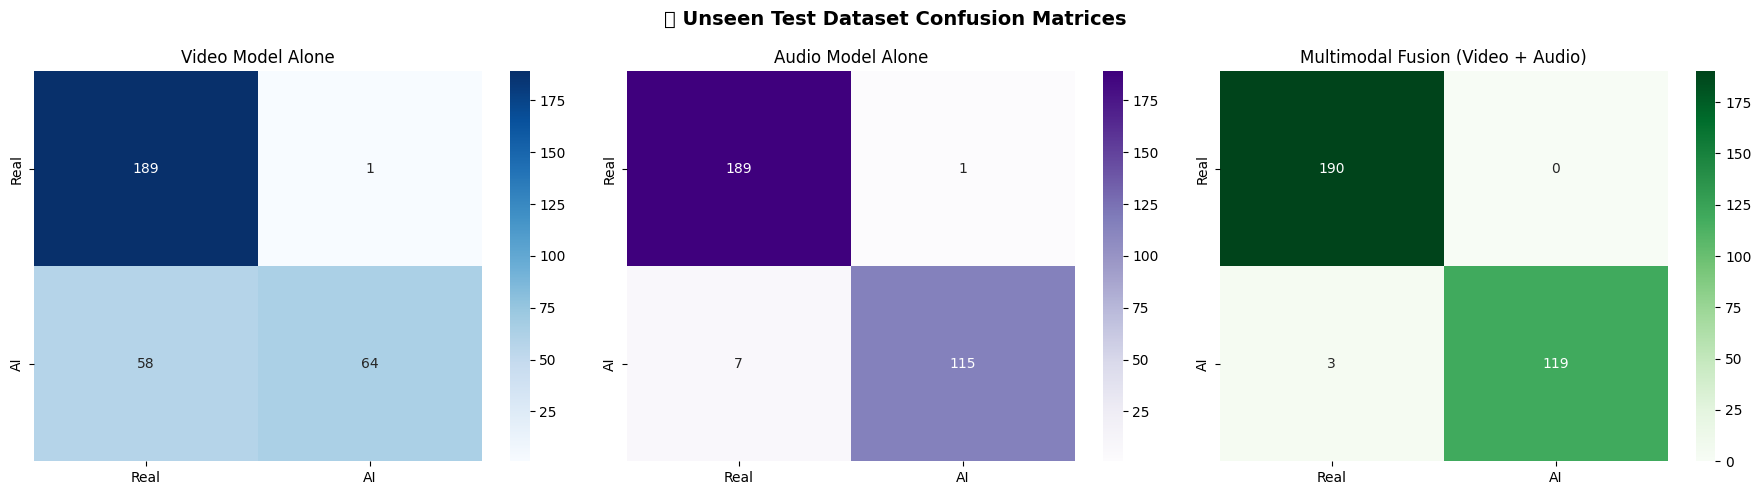

In [54]:
# Print Test Reports
if not test_videos:
    print("❌ Evaluation skipped: No test videos loaded.")
else:
    print("==================================================")
    print("🏁 TEST DATASET: VIDEO-ONLY MODEL PERFORMANCE")
    print("==================================================")
    print(classification_report(test_targets, test_video_preds, target_names=CLASSES))

    print("==================================================")
    print("🏁 TEST DATASET: AUDIO-ONLY MODEL PERFORMANCE")
    print("==================================================")
    print(classification_report(test_targets, test_audio_preds, target_names=CLASSES))

    print("==================================================")
    print("🏁 TEST DATASET: MULTIMODAL FUSION PERFORMANCE")
    print("==================================================")
    print(classification_report(test_targets, test_fusion_preds, target_names=CLASSES))

    # Plot Test Confusion Matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("🏁 Unseen Test Dataset Confusion Matrices", fontsize=14, fontweight='bold')

    cm_vid_test = confusion_matrix(test_targets, test_video_preds)
    sns.heatmap(cm_vid_test, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title("Video Model Alone")

    cm_aud_test = confusion_matrix(test_targets, test_audio_preds)
    sns.heatmap(cm_aud_test, annot=True, fmt="d", cmap="Purples", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title("Audio Model Alone")

    cm_fusion_test = confusion_matrix(test_targets, test_fusion_preds)
    sns.heatmap(cm_fusion_test, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
    axes[2].set_title("Multimodal Fusion (Video + Audio)")

    plt.tight_layout()
    plt.show()


## 11. Test Multimodal Inference on Any Video

In [55]:
def predict_multimodal_video(video_path, w_video=0.5, w_audio=0.5):
    """
    Predicts Real vs AI for any video by combining Visual Video Frame features 
    and Audio Voice features.
    """
    print(f"🎬 Processing video: {video_path}")
    
    p_vid = predict_video_probs(video_path)
    p_aud = predict_audio_probs(video_path)
    
    p_multimodal = (w_video * p_vid) + (w_audio * p_aud)
    
    pred_idx = np.argmax(p_multimodal)
    pred_label = CLASSES[pred_idx]
    confidence = p_multimodal[pred_idx]

    print("--- Model Output Scores ---")
    print(f"📹 Video Model Confidence: {CLASSES[np.argmax(p_vid)]} ({np.max(p_vid)*100:.2f}%)")
    print(f"🎙️ Audio Model Confidence: {CLASSES[np.argmax(p_aud)]} ({np.max(p_aud)*100:.2f}%)")
    print(f"🤝 COMBINED MULTIMODAL RESULT: {pred_label} ({confidence*100:.2f}% confidence)")
    
    return pred_label, confidence

# Example Usage:
# test_vid = "/content/dataset_test/Real/sample_test_video.mp4"
# label, conf = predict_multimodal_video(test_vid, w_video=0.5, w_audio=0.5)


In [56]:
import pandas as pd

# 1. Structure the test results
test_results = []
for idx, (vfile, label, cls_name, vid_stem) in enumerate(test_videos):
    test_results.append({
        "video_path": vfile,
        "video_name": vid_stem,
        "ground_truth": CLASSES[label],
        "video_pred": CLASSES[test_video_preds[idx]],
        "audio_pred": CLASSES[test_audio_preds[idx]],
        "multimodal_fusion_pred": CLASSES[test_fusion_preds[idx]],
        "correct": test_fusion_preds[idx] == label
    })

# 2. Convert to DataFrame and save to Google Drive
df_results = pd.DataFrame(test_results)
csv_save_path = "/content/drive/MyDrive/Gemastik26/test_predictions.csv"
df_results.to_csv(csv_save_path, index=False)

print(f"💾 SUCCESS: Test predictions successfully saved to Drive at:\n➡️ {csv_save_path}")
print(f"   Total rows saved: {len(df_results)}")

# Show preview
display(df_results.head(10))


💾 SUCCESS: Test predictions successfully saved to Drive at:
➡️ /content/drive/MyDrive/Gemastik26/test_predictions.csv
   Total rows saved: 312


,video_path,video_name,ground_truth,video_pred,audio_pred,multimodal_fusion_pred,correct
0,/content/dataset_test/Real/testReal/112.mp4,112,Real,Real,Real,Real,True
1,/content/dataset_test/Real/testReal/82.mp4,82,Real,Real,Real,Real,True
2,/content/dataset_test/Real/testReal/190.mp4,190,Real,Real,Real,Real,True
3,/content/dataset_test/Real/testReal/101.mp4,101,Real,Real,Real,Real,True
4,/content/dataset_test/Real/testReal/83.mp4,83,Real,Real,Real,Real,True
5,/content/dataset_test/Real/testReal/158.mp4,158,Real,Real,Real,Real,True
6,/content/dataset_test/Real/testReal/110.mp4,110,Real,AI,Real,Real,True
7,/content/dataset_test/Real/testReal/133.mp4,133,Real,Real,Real,Real,True
8,/content/dataset_test/Real/testReal/17.mp4,17,Real,Real,Real,Real,True
9,/content/dataset_test/Real/testReal/138.mp4,138,Real,Real,Real,Real,True
